# Slope Fields
Code to render slope field

**To evalute cells, type shift + enter.**

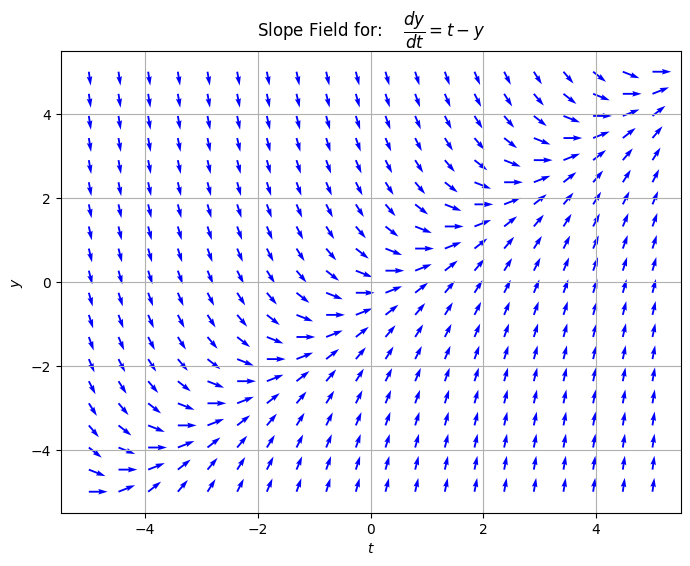

In [ ]:
# Define the differential equation
def dydt(t, y):
    return

# Create a grid of t and y values
t     = np.linspace(-5, 5, 20)
y     = np.linspace(-5, 5, 20)
[T,Y] = np.meshgrid(t, y)

# Calculate the slopes at each point defined by dy/dt = f(t,y)
slopes = dydx(T, Y)

# Normalize the vectors to have uniform length
dt = np.ones(slopes.shape)
dy = slopes
# Normalize the vectors
magnitude = np.sqrt(dt**2 + dy**2)
dt_norm = dt / magnitude
dy_norm = dy / magnitude

plt.figure(figsize=(8, 6))
plt.quiver(T, Y, dt_norm, dy_norm, angles='xy', scale_units='xy', scale=3, color='blue')
plt.xlabel(r'$t$')
plt.ylabel(r'$y$')
plt.title(r'Slope Field for: $\quad \dfrac{dy}{dt} = t - y$')
plt.grid(True)
plt.show()


# Euler's Method
Python code below performs Euler's Method.

**To evalute cells, type shift + enter.**

In [7]:
# importing libraries
import numpy as np
import math
from matplotlib import pyplot as plt
from ipywidgets import interactive, fixed

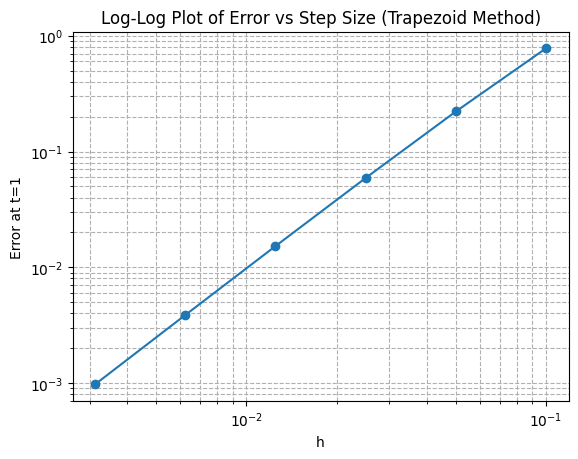

In [13]:
# Euler's Method routine for solving Initial Value Problems (IVPs)
# Use with ydot.m to evaluate rhs of differential equation
# Input: interval inter, initial value y0, number of steps n
# Output: time steps t, approximate solution w
# Usage: euler(a,b,y_0,n)
# Example: euler(0,1,1,10)

# Euler's Method routine for solving Initial Value Problems (IVPs)
def euler(a, b, y0, n):

    # initialize/define
    t    = np.zeros(n+1)  # independent var
    w    = np.zeros(n+1)  # dependent var
    h    = (b-a)/n        # step size
    w[0] = y0             # initial condition

    for i in range(1, n+1):
        t[i] = t[i-1] + h
        w[i] = w[i-1] + h*f(t[i-1], w[i-1])
    return t, w

# ----------------------------
# Explicit Trapezoid Method
# ----------------------------
def trap(a, b, y0, n):

    # initialize/define
    t    = np.zeros(n+1)  # independent var
    w    = np.zeros(n+1)  # dependent var
    h    = (b-a)/n        # step size
    w[0] = y0             # initial condition

    for i in range(1, n+1):
        t[i] = t[i-1] + h

        # Predictor step (Euler estimate)
        w_tilde = w[i-1] + h*f(t[i-1], w[i-1])

        # Corrector step (Trapezoid formula)
        w[i] = w[i-1] + (h/2) * (f(t[i-1], w[i-1]) + f(t[i], w_tilde))

    return t, w

# RHS of Differential Equation
def f(t,y):
    ydot = 2*(t + 1)*y
    return ydot

# Exact solution
def exact_solution(t):
    return np.exp(2*t*(1 + t/2))

# Problem parameters
a, b, y0 = 0, 1, 1

# Error list
h_values = []
errors = []

for k in range(6):
    h = 0.1 * 2**(-k)
    n = int((b - a) / h)

    # Use trapezoid method instead of Euler
    t, w = trap(a, b, y0, n)

    y_exact = exact_solution(1)
    error = abs(y_exact - w[-1])

    h_values.append(h)
    errors.append(error)

# Log-log plot
plt.loglog(h_values, errors, '-o')
plt.xlabel('h')
plt.ylabel('Error at t=1')
plt.title('Log-Log Plot of Error vs Step Size (Trapezoid Method)')
plt.grid(True, which="both", ls="--")
plt.show()


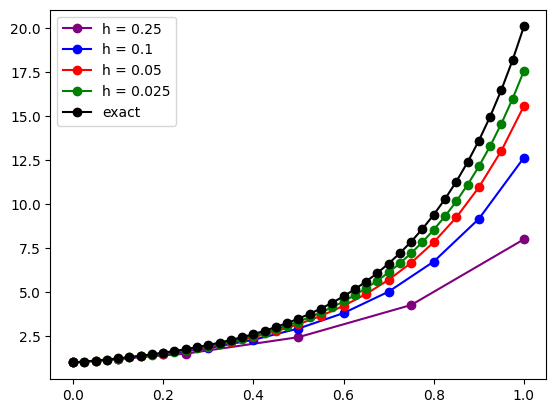

In [ ]:
# evaluation of euler's method for decreasing values of step size h
# and corresponding plots.
[t,w]   = euler(a,b,y0,n)

plt.plot(t4,w4,'-o',color='purple',label = "h = 0.25")
plt.plot(t10,w10,'-o',color='blue',label = "h = 0.1")

y_exact =
plt.plot(t40,y,'-o',color='black',label = "exact")
plt.legend()

Text(0, 0.5, '$|y(b) - w_{n}|$ (error)')

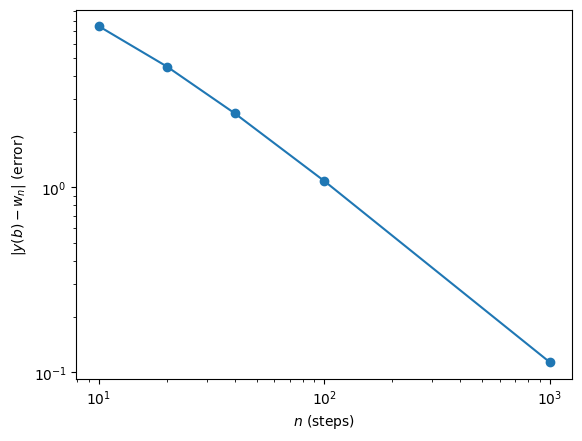

In [ ]:
# Error e at t = b for decreasing (increasing) h (n).
w1 = [w10[-1], w20[-1], w40[-1], w100[-1], w1000[-1]]
e = np.abs(y[-1] - w1)
n = [10,20,40,100,1000]
p = plt.loglog(n,e,'-o')
plt.xlabel(r'$n$ (steps)')
plt.ylabel(r'$|y(b) - w_{n}|$ (error)')